In [1]:
import numpy as np
import pandas as pd
import lasio as las
from glob import glob
import matplotlib.pyplot as plt
import scipy
import os

from util.filehandler import read_las
from util.plotting import plot_well_logs
from util.well_processing import filter_wells_by_lithology, prepare_valid_tagilsk

In [10]:
las_files = glob('/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/*Tgl*.las')
las_files

[]

In [9]:
test = glob('smb://truenas-scale/Documents Share/*')
test

[]

In [3]:
# Create a dictionary to store all DataFrames
las_dfs = read_las(las_files)
# Keep only needed curves
las_dfs = prepare_valid_tagilsk(las_dfs)
# Display the keys (well names) in the dictionary
print(f"\nTotal wells loaded: {len(las_dfs)}")
print(f"Well names: {list(las_dfs.keys())}")

Loaded: Tgl-30 - 4603 rows, 14 curves
Loaded: Tgl-26 - 6062 rows, 15 curves
Loaded: ZTgl-1 - 5408 rows, 12 curves
Loaded: Tgl-15 - 5898 rows, 14 curves
Loaded: Tgl-29 - 29873 rows, 14 curves
Loaded: Tgl-8 - 7623 rows, 16 curves
Loaded: Tgl-27 - 2377 rows, 12 curves
Processing well Tgl-30
Processing well Tgl-26
Processing well ZTgl-1
Processing well Tgl-15
Processing well Tgl-29
Processing well Tgl-8
Processing well Tgl-27

Total wells loaded: 7
Well names: ['Tgl-30', 'Tgl-26', 'ZTgl-1', 'Tgl-15', 'Tgl-29', 'Tgl-8', 'Tgl-27']


(<Figure size 850x1200 with 5 Axes>,
 array([<Axes: title={'center': 'NAS'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'LITH'}>, <Axes: title={'center': 'VP'}>,
        <Axes: title={'center': 'VS'}>, <Axes: title={'center': 'PL_GG'}>],
       dtype=object))

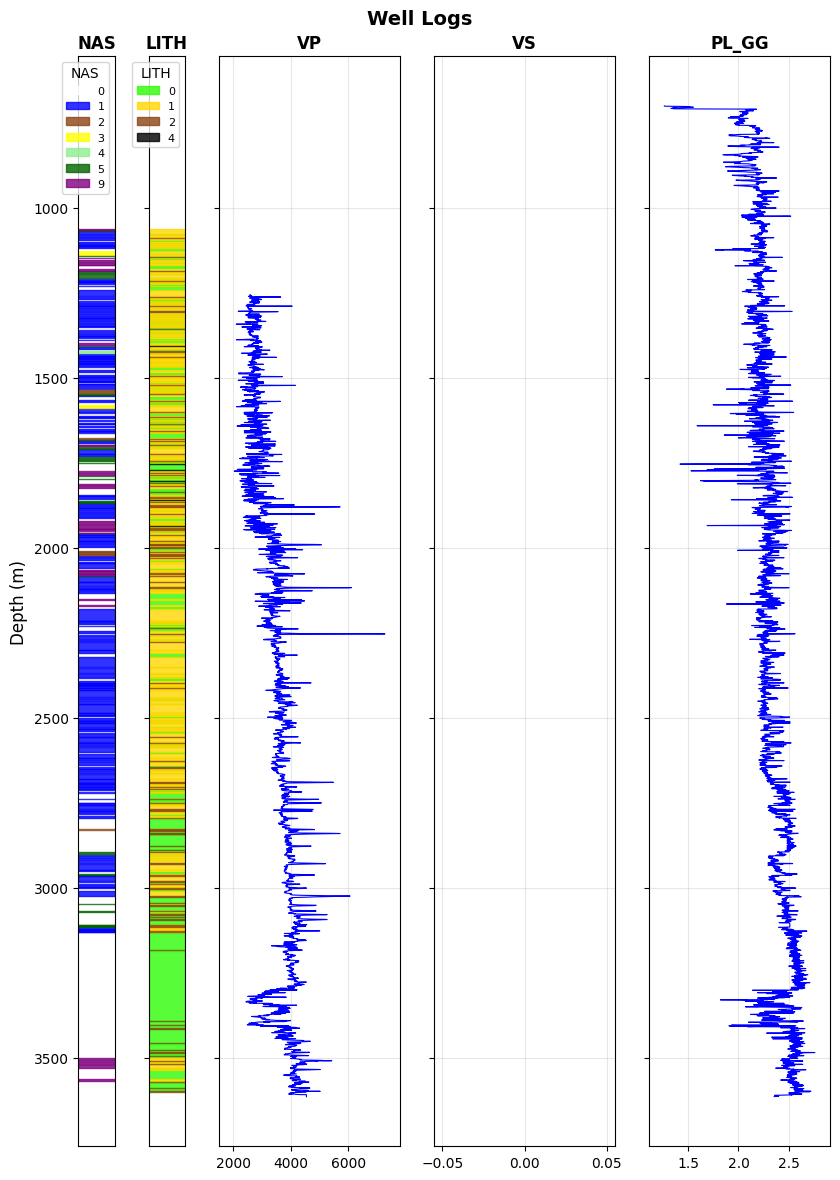

In [27]:
plot_well_logs(las_dfs['Tgl-15'], ['NAS', 'LITH', 'VP', 'VS', 'PL_GG'])

In [5]:
las_dfs_shale = {}
las_dfs_brine_sand = {}
las_dfs_oil_sand = {}
las_dfs_gas_sand = {}

# Apply filtering to all wells
las_dfs_shale, las_dfs_brine_sand, las_dfs_oil_sand, las_dfs_gas_sand = filter_wells_by_lithology(las_dfs)

Tgl-30: shale=2260, brine=1707, oil=142, gas=4
Tgl-26: shale=2806, brine=2255, oil=446, gas=94
ZTgl-1: shale=2184, brine=2217, oil=0, gas=0
Tgl-15: shale=2430, brine=1939, oil=427, gas=285
Tgl-29: shale=15536, brine=12102, oil=1081, gas=194
Tgl-8: shale=3158, brine=723, oil=1774, gas=55
Tgl-27: shale=848, brine=46, oil=215, gas=34


# Probabalistic models implementation

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

def fit_gp_model(df, property_col, random_state=42):
    """
    Fit a Gaussian Process model to depth-property data.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with depth as index
    property_col : str
        Column name (e.g., 'Vp', 'Vs', 'PL_GG')
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    dict with keys:
        'model' : fitted GPR model
        'depth_range' : (min_depth, max_depth)
        'r2_score' : model fit quality
    """
    # Extract data, drop NaNs
    data = df[[property_col]].dropna()
    X = data.index.values.reshape(-1, 1)  # depth as 2D array
    y = data[property_col].values
    
    if len(X) < 10:
        print(f"Warning: Only {len(X)} data points for {property_col}")
        return None
    
    # Define kernel: RBF (smooth trend) + WhiteKernel (noise)
    kernel = ConstantKernel(1.0) * RBF(length_scale=100.0) + WhiteKernel(noise_level=1.0)
    
    # Fit GPR
    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=random_state)
    gpr.fit(X, y)
    
    # Calculate R² score on training data
    y_pred = gpr.predict(X)
    r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)
    
    depth_min, depth_max = X.min(), X.max()
    
    print(f"{property_col}: R² = {r2:.3f}, kernel = {gpr.kernel_}")
    
    return {
        'model': gpr,
        'depth_range': (depth_min, depth_max),
        'r2_score': r2
    }

def fit_gp_model_all_wells(las_dfs_dict, property_col, max_points=2000, random_state=42):
    """
    Fit a GP model on subsampled data from all wells.
    """
    all_data = []
    
    for well_name, df in las_dfs_dict.items():
        if property_col in df.columns:
            subset = df[[property_col]].dropna()
            all_data.append(subset)
    
    if not all_data:
        print(f"No data found for {property_col}")
        return None
    
    combined_df = pd.concat(all_data)
    
    # Subsample if too many points
    if len(combined_df) > max_points:
        combined_df = combined_df.sample(n=max_points, random_state=random_state)
        print(f"Subsampled to {max_points} points")
    
    print(f"Using {len(combined_df)} points for {property_col}")
    
    return fit_gp_model(combined_df, property_col, random_state)

result_shale_plgg = fit_gp_model_all_wells(las_dfs_shale, 'PL_GG', max_points=4000)

Combined 29213 points from 7 wells for PL_GG


<Axes: title={'center': 'GP Model: PL_GG'}, xlabel='Depth (m)', ylabel='PL_GG'>

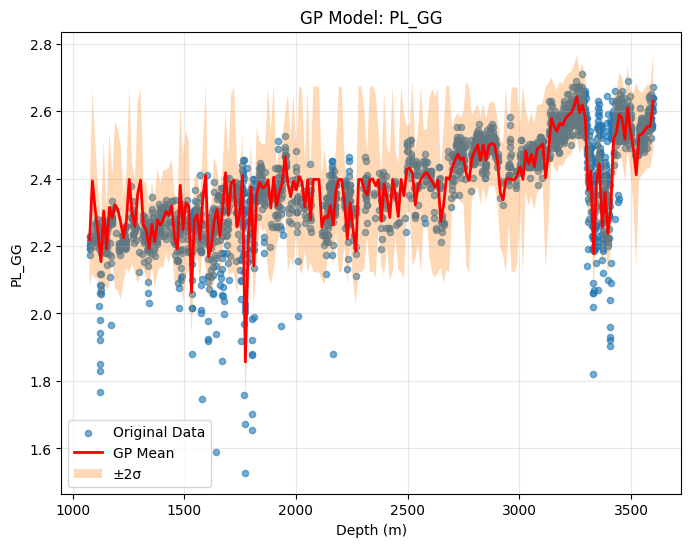

In [ ]:
def plot_gp_model(gp_result, property_col, ax=None):
    """
    Plot GP model with original data.
    
    Parameters:
    -----------
    gp_result : dict
        Output from fit_gp_model()
    property_col : str
        Property name (for labels)
    ax : matplotlib axis object
        If None, creates new figure
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    model = gp_result['model']
    
    # Denormalize the stored training data
    X_orig = model.X_train_.flatten()
    y_orig = model.y_train_ * model._y_train_std + model._y_train_mean
    
    # Generate smooth curve from GP
    x_smooth = np.linspace(X_orig.min(), X_orig.max(), 200).reshape(-1, 1)
    y_mean, y_std = model.predict(x_smooth, return_std=True)
    
    # Plot
    ax.scatter(X_orig, y_orig, alpha=0.6, label='Original Data', s=20)
    ax.plot(x_smooth, y_mean, 'r-', label='GP Mean', linewidth=2)
    ax.fill_between(x_smooth.flatten(), 
                   y_mean - 2*y_std, 
                   y_mean + 2*y_std, 
                   alpha=0.3, label='±2σ')
    
    ax.set_xlabel('Depth (m)')
    ax.set_ylabel(property_col)
    ax.set_title(f'GP Model: {property_col}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return ax
plot_gp_model(result_shale_plgg, 'PL_GG')

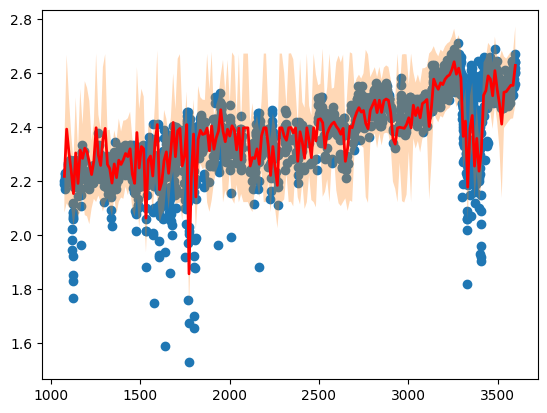

In [ ]:
x = las_dfs_shale['Tgl-15']['DEPTH']
y = las_dfs_shale['Tgl-15']['PL_GG']
x_smooth = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_mean, y_std = result['model'].predict(x_smooth, return_std=True)
plt.scatter(x, y)
plt.plot(x_smooth, y_mean, 'r-', label='GP Mean', linewidth=2)
plt.fill_between(x_smooth.flatten(), 
                y_mean - 2*y_std, 
                y_mean + 2*y_std, 
                alpha=0.3, label='±2σ')


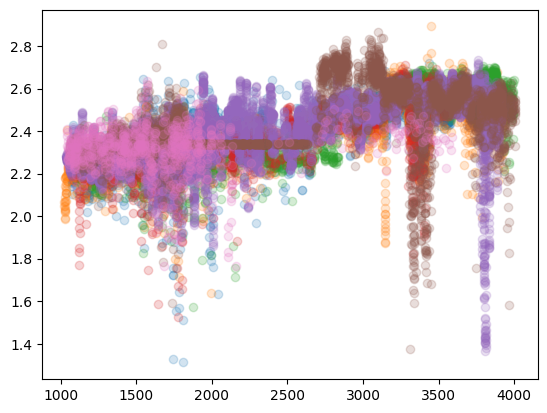

In [37]:
for well in las_dfs_shale.keys():
    x = las_dfs_shale[well]['DEPTH']
    y = las_dfs_shale[well]['PL_GG']
    plt.scatter(x, y, alpha=0.2)